# Part 4 — Unbatched + Cache (decrease cost, preserve accuracy)

**Question:** can per-puzzle caching of gold-prompt verdicts cut the unbatched evaluator's cost without giving up accuracy?

Mechanism: with `--batch no --cache`, the unbatched evaluator stores every `(clue_text, constraint) → verdict` it sees within a puzzle. DFS siblings often share many testable clues, so subsequent calls hit the cache and skip the API.

In [1]:
import json, glob, statistics
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# Walk up from cwd to the repo root (where 'results/' and 'data/' live).
# Robust to Jupyter being launched from the notebook dir or the repo root.
ROOT = Path.cwd().resolve()
while not ((ROOT / 'results').is_dir() and (ROOT / 'data').is_dir()):
    if ROOT == ROOT.parent:
        raise RuntimeError(f"can't find repo root from {Path.cwd()}")
    ROOT = ROOT.parent
RUNS = ROOT / 'results' / 'crosswords' / 'runs'
assert RUNS.is_dir()

PLOTS = ROOT / 'code' / 'analysis' / 'crosswords' / 'plots'
PLOTS.mkdir(parents=True, exist_ok=True)

# ---------------- Report palette ----------------
CHARCOAL = '#233d4d'
PUMPKIN  = '#fe7f2d'
GOLDEN   = '#fcca46'
OLIVE    = '#a1c181'
SEAGRASS = '#619b8a'

mpl.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'axes.edgecolor':CHARCOAL,'axes.labelcolor':CHARCOAL,'axes.titlecolor':CHARCOAL,
    'axes.titleweight':'bold','axes.labelweight':'bold',
    'axes.titlesize':14,'axes.labelsize':12,'axes.linewidth':1.6,
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':False,
    'xtick.color':CHARCOAL,'ytick.color':CHARCOAL,
    'xtick.labelsize':11,'ytick.labelsize':11,
    'xtick.major.size':0,'ytick.major.size':4,
    'font.weight':'bold','font.family':'sans-serif',
    'legend.frameon':False,'legend.fontsize':11,
    'lines.linewidth':2.6,'lines.markersize':9,
    'savefig.dpi':150,'savefig.bbox':'tight',
})

## 1. Helpers

In [2]:
def grid_metrics(grid, gt):
    flat = [c.upper() for r in grid for c in r]
    truth = [c.upper() for c in gt]
    if len(flat) != 25: return 0.0, 0.0, 0.0
    cl = sum(1 for o, t in zip(flat, truth) if o == t)
    cw = sum(1 for i in range(5) if flat[i*5:(i+1)*5] == truth[i*5:(i+1)*5])
    cw += sum(1 for i in range(5) if flat[i::5] == truth[i::5])
    return cl/25, cw/10, 1.0 if cl == 25 else 0.0

def load_runs(pattern, expected_n=20):
    out = []
    for fp in sorted(glob.glob(str(RUNS/pattern))):
        with open(fp) as f:
            rows = [json.loads(line) for line in f if line.strip()]
        if len(rows) >= expected_n:
            out.append({'file': Path(fp).name, 'rows': rows})
    return out

def run_metrics(rows):
    Ls, Ws, Gs, Ss, Cs, Ts, Pc, Vc = [], [], [], [], [], [], [], []
    for r in rows:
        l, w, g = grid_metrics(r['grid'], r['ground_truth'])
        Ls.append(l); Ws.append(w); Gs.append(g)
        Ss.append(r.get('expansions', 0))
        Cs.append(r.get('llm_calls_total', 0))
        Ts.append(r.get('runtime_sec', r.get('elapsed_s', 0)))
        Pc.append(r.get('llm_calls_propose', 0))
        Vc.append(r.get('llm_calls_value', 0))
    return {
        'letter': statistics.mean(Ls)*100, 'word': statistics.mean(Ws)*100,
        'game':   statistics.mean(Gs)*100, 'steps': statistics.mean(Ss),
        'calls':  statistics.mean(Cs),     'secs':  statistics.mean(Ts),
        'propose': statistics.mean(Pc),    'value': statistics.mean(Vc),
    }

def aggregate(runs, label):
    if not runs: return None
    per_run = [run_metrics(r['rows']) for r in runs]
    out = {'label': label, 'n_runs': len(per_run), 'per_run': per_run}
    for k in ('letter', 'word', 'game', 'steps', 'calls', 'secs', 'propose', 'value'):
        vs = [m[k] for m in per_run]
        out[f'{k}_mean'] = statistics.mean(vs)
        out[f'{k}_se']   = statistics.pstdev(vs)/(len(vs)**0.5) if len(vs) > 1 else 0.0
        out[f'{k}_runs'] = vs
    return out

## 2. Load `unbatched` and `unbatched_cache` plus references

In [3]:
patterns = {
    'unbatched':       'cw_gem31_tot_unbatched_s100_prune_backtrack_papersplit*.jsonl',
    'unbatched_cache': 'cw_gem31_tot_unbatched_cache_s100_prune_backtrack_papersplit*.jsonl',
    'half_focused':    'cw_gem31_tot_half_focused_s100_prune_backtrack_papersplit*.jsonl',
    'half_focused_k7': 'cw_gem31_tot_half_focused_k7_s100_prune_backtrack_papersplit*.jsonl',
    'full_focused':    'cw_gem31_tot_full_focused_s100_prune_backtrack_papersplit*.jsonl',
    'full_basic':      'cw_gem31_tot_full_basic_s100_prune_backtrack_papersplit*.jsonl',
    'half_basic':      'cw_gem31_tot_half_basic_s100_prune_backtrack_papersplit*.jsonl',
}
cells = {k: aggregate(load_runs(p), k) for k, p in patterns.items()}

print(f'{"cell":18s}{"runs":>5}{"L%":>9}{"W%":>9}{"G%":>11}{"calls":>8}{"P":>6}{"V":>6}{"steps":>8}{"sec":>7}')
print('-'*82)
for k, c in cells.items():
    if c is None: continue
    print(f'{k:18s}{c["n_runs"]:>5}'
          f'  {c["letter_mean"]:>5.1f}'
          f'  {c["word_mean"]:>5.1f}'
          f'  {c["game_mean"]:>5.1f}±{c["game_se"]:.1f}'
          f'  {c["calls_mean"]:>5.0f}'
          f'  {c["propose_mean"]:>4.0f}'
          f'  {c["value_mean"]:>4.0f}'
          f'  {c["steps_mean"]:>5.1f}'
          f'  {c["secs_mean"]:>5.0f}')

cell               runs       L%       W%         G%   calls     P     V   steps    sec
----------------------------------------------------------------------------------
unbatched             5   77.4   59.1   33.0±2.3    462   122   340   24.3    556
unbatched_cache       3   77.1   61.5   40.0±4.1    347   135   212   27.0    373
half_focused          4   80.1   60.5   36.2±2.1    405   141   264   28.1    473
half_focused_k7       4   82.2   63.4   36.2±3.2    421   148   273   29.6    652
full_focused          4   74.8   54.0   27.5±2.8    118    98    20   19.6    167
full_basic            5   72.7   50.6   24.0±2.2    158   135    23   26.9    226
half_basic            5   77.6   55.6   25.0±1.4    414   186   228   37.2    500


## 3. Plots

### Game Accuracy

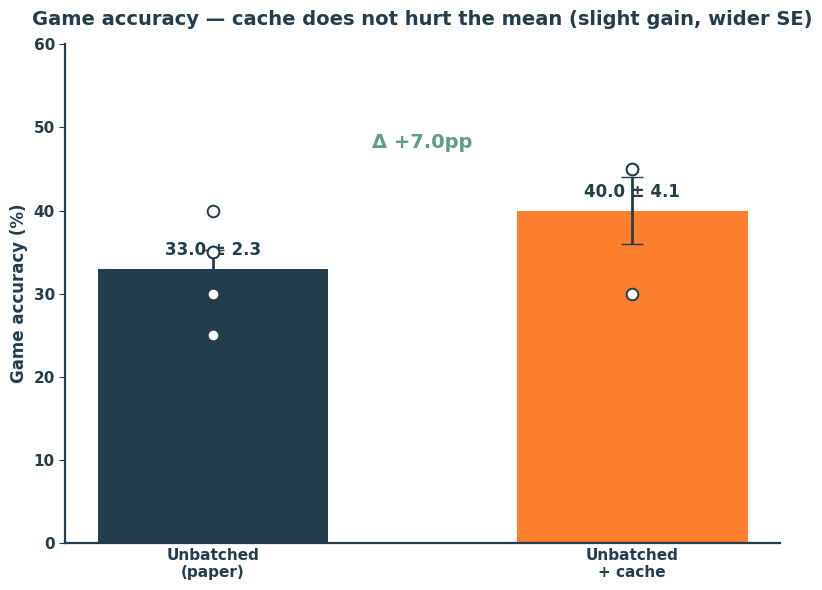

In [4]:
configs = ['unbatched', 'unbatched_cache']
labels  = ['Unbatched\n(paper)', 'Unbatched\n+ cache']
colors  = [CHARCOAL, PUMPKIN]

fig, ax = plt.subplots(figsize=(8, 6))
x = np.arange(len(configs))
for i, (key, color) in enumerate(zip(configs, colors)):
    c = cells[key]
    ax.bar(i, c['game_mean'], 0.55, color=color, edgecolor='none',
           yerr=c['game_se'], capsize=8,
           error_kw={'elinewidth': 2.0, 'ecolor': CHARCOAL})
    ax.scatter([i]*len(c['game_runs']), c['game_runs'],
               color='white', edgecolor=CHARCOAL, linewidth=1.4, s=70, zorder=4)
    ax.text(i, c['game_mean'] + 1.6, f'{c["game_mean"]:.1f} ± {c["game_se"]:.1f}',
            ha='center', fontsize=12, color=CHARCOAL, fontweight='bold')

delta = cells['unbatched_cache']['game_mean'] - cells['unbatched']['game_mean']
ax.annotate(f'Δ {delta:+.1f}pp', xy=(0.5, max(cells[c]['game_mean'] for c in configs) + 7.5),
            ha='center', fontsize=14, color=SEAGRASS if delta > 0 else PUMPKIN,
            fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Game accuracy (%)')
ax.set_ylim(0, 60)
ax.set_title('Game accuracy — cache does not hurt the mean (slight gain, wider SE)', pad=14)
fig.tight_layout()
plt.show()

### Cost composition

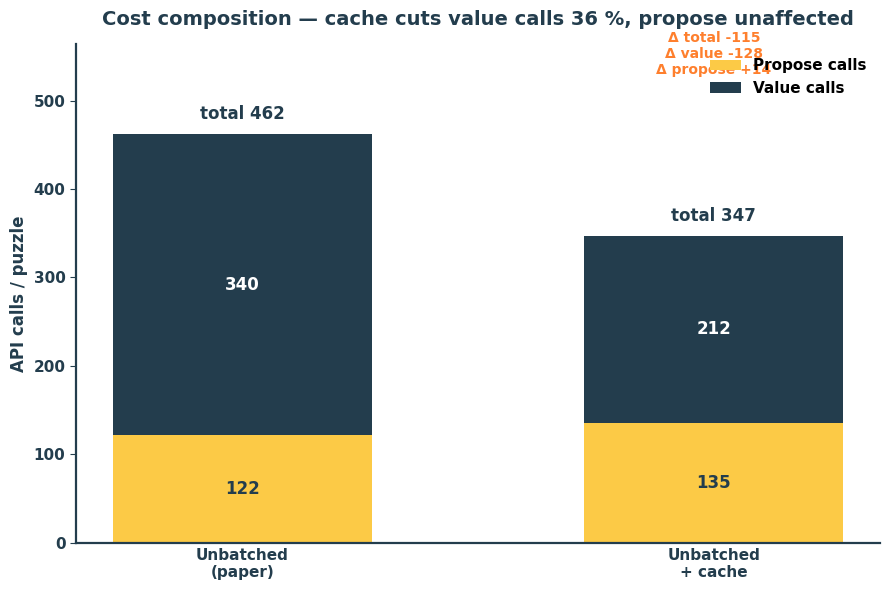

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(configs))
propose_vals = [cells[k]['propose_mean'] for k in configs]
value_vals   = [cells[k]['value_mean']   for k in configs]
totals       = [p + v for p, v in zip(propose_vals, value_vals)]

ax.bar(x, propose_vals,                    color=GOLDEN,   label='Propose calls', edgecolor='none', width=0.55)
ax.bar(x, value_vals, bottom=propose_vals, color=CHARCOAL, label='Value calls',   edgecolor='none', width=0.55)

ymax = max(totals) * 1.22
for xi, p, v, total in zip(x, propose_vals, value_vals, totals):
    ax.text(xi, p/2,         f'{p:.0f}', ha='center', va='center', color=CHARCOAL, fontsize=12, fontweight='bold')
    ax.text(xi, p + v/2,     f'{v:.0f}', ha='center', va='center', color='white',  fontsize=12, fontweight='bold')
    ax.text(xi, total + ymax*0.03, f'total {total:.0f}',
            ha='center', fontsize=12, color=CHARCOAL, fontweight='bold')

# Δ annotations
delta_total   = totals[1] - totals[0]
delta_value   = value_vals[1] - value_vals[0]
delta_propose = propose_vals[1] - propose_vals[0]
ax.text(1, ymax*0.94,
        f'Δ total {delta_total:+.0f}\nΔ value {delta_value:+.0f}\nΔ propose {delta_propose:+.0f}',
        ha='center', fontsize=10, color=PUMPKIN, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('API calls / puzzle')
ax.set_ylim(0, ymax)
ax.set_title('Cost composition — cache cuts value calls 36 %, propose unaffected', pad=14)
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

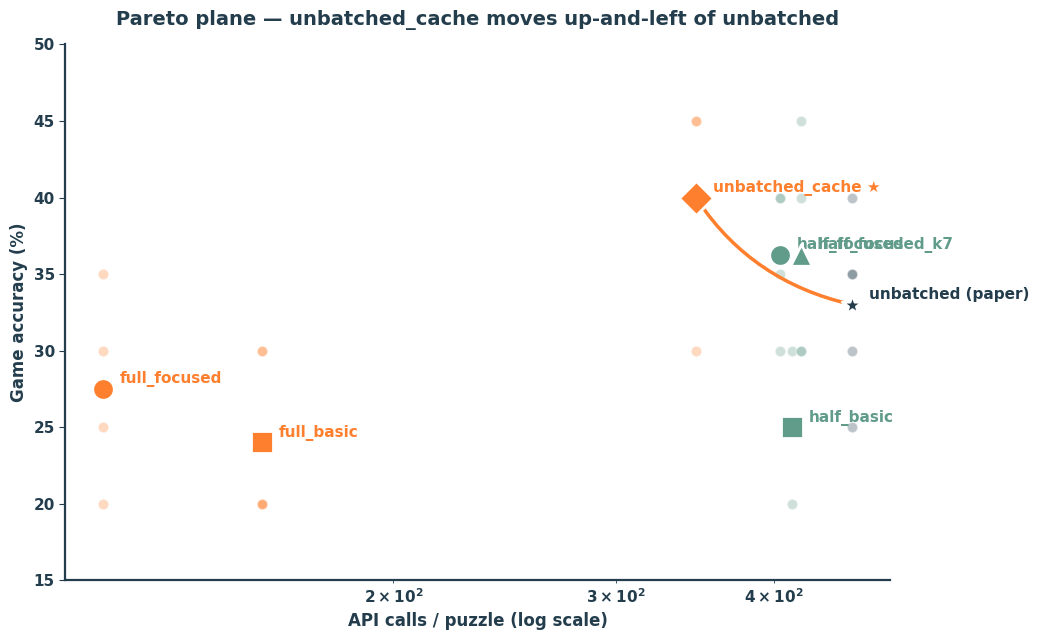

In [6]:
pareto_items = [
    ('full_basic',      PUMPKIN,  's', 'full_basic'),
    ('full_focused',    PUMPKIN,  'o', 'full_focused'),
    ('half_basic',      SEAGRASS, 's', 'half_basic'),
    ('half_focused',    SEAGRASS, 'o', 'half_focused'),
    ('half_focused_k7', SEAGRASS, '^', 'half_focused_k7'),
    ('unbatched',       CHARCOAL, '*', 'unbatched (paper)'),
    ('unbatched_cache', PUMPKIN,  'D', 'unbatched_cache ★'),
]

fig, ax = plt.subplots(figsize=(10.5, 6.5))
for key, color, marker, label in pareto_items:
    c = cells.get(key)
    if c is None: continue
    # Run dots (fade)
    ax.scatter([c['calls_mean']]*len(c['game_runs']), c['game_runs'],
               s=55, color=color, alpha=0.30, edgecolor='white', zorder=2)
    # Mean point
    ax.scatter(c['calls_mean'], c['game_mean'], s=300 if 'cache' in key else 240,
               color=color, marker=marker, edgecolor='white', linewidth=2.0, zorder=4)
    ax.annotate(label, (c['calls_mean'], c['game_mean']),
                xytext=(12, 4), textcoords='offset points',
                fontsize=11, color=color, fontweight='bold')

# Pareto-improvement arrow: unbatched -> unbatched_cache
u  = cells['unbatched']
uc = cells['unbatched_cache']
ax.annotate('', xy=(uc['calls_mean'], uc['game_mean']),
            xytext=(u['calls_mean'], u['game_mean']),
            arrowprops=dict(arrowstyle='->', color=PUMPKIN, lw=2.5,
                            connectionstyle='arc3,rad=-0.2'))

ax.set_xscale('log')
ax.set_xlabel('API calls / puzzle (log scale)')
ax.set_ylabel('Game accuracy (%)')
ax.set_ylim(15, 50)
ax.set_title('Pareto plane — unbatched_cache moves up-and-left of unbatched', pad=14)
fig.tight_layout()
plt.show()